In [2]:
import os, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import glob, math
from scipy import signal
from scipy.fft import rfft, rfftfreq
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
%matplotlib inline

In [3]:
# Remove junk files starting with "._" using the CLI command: 
# "Get-ChildItem -Recurse -Filter "._*" | Remove-Item"

In [4]:
data_path = "../NeurIT/NeurIT-dataset/uniform_data/"
# print(os.path.exists(data_path))

splits = ["test_seen", "test_unseen", "train_dataset", "val_dataset"]
for split in splits:
    split_path = os.path.join(data_path, split)
    offices = os.listdir(split_path)
    print(split, "→", len(offices), "office folders")

test_seen → 15 office folders
test_unseen → 19 office folders
train_dataset → 60 office folders
val_dataset → 15 office folders


In [5]:
def load_sample(split):
    split_path = os.path.join(data_path, split)
    office = os.listdir(split_path)[13]
    folder = os.path.join(split_path, office)

    raw = np.load(os.path.join(folder, "rawdata.npy"))
    gt = np.load(os.path.join(folder, "groundtruth.npy"))

    return raw, gt, office

for split in splits:
    raw, gt, office = load_sample(split)
    print(f"{split:<{13}} | {office:<{13}} | raw_shape={raw.shape} | gt_shape={gt.shape}")

test_seen     | hw5floor14    | raw_shape=(73585, 10) | gt_shape=(73585, 8)
test_unseen   | cymbuilding15 | raw_shape=(68520, 10) | gt_shape=(68520, 8)
train_dataset | 101office21   | raw_shape=(129127, 10) | gt_shape=(129127, 8)
val_dataset   | hw5floor14    | raw_shape=(83476, 10) | gt_shape=(83476, 8)


##### The raw data has 10 features:
- 1 represents timestamps
- 3 from gyroscope
- 3 from accelerometer
- 3 from magnetometer
(in order)
---
##### The ground truth has 8 features:
- 1 represents timestamps
- position - 3D
- orientation - 4D(quaternions)
(in order)

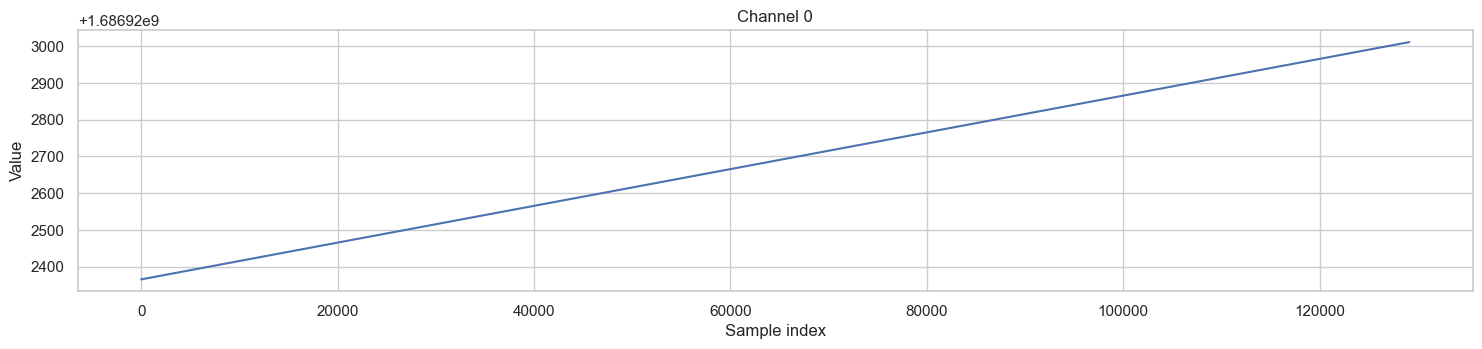

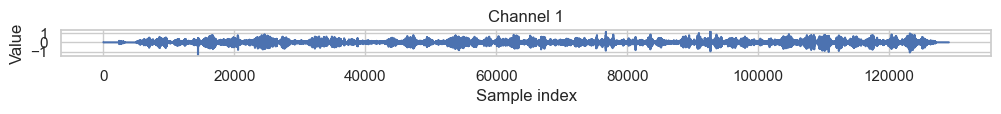

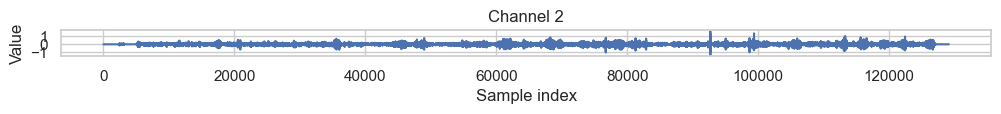

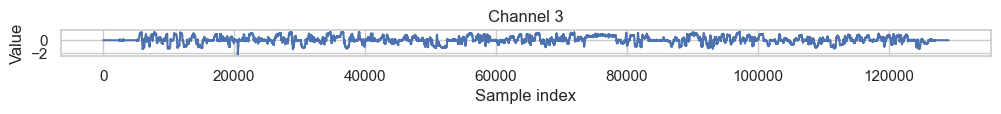

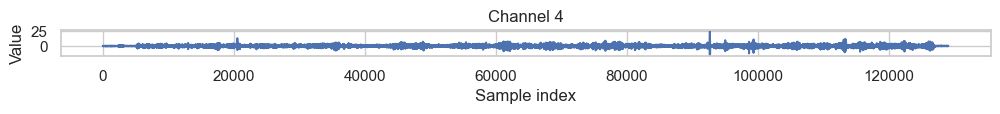

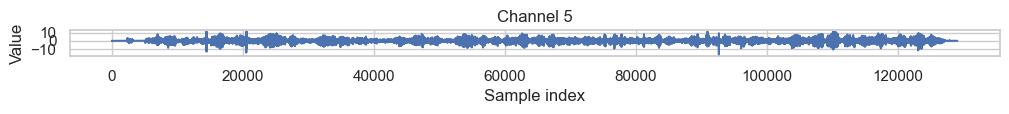

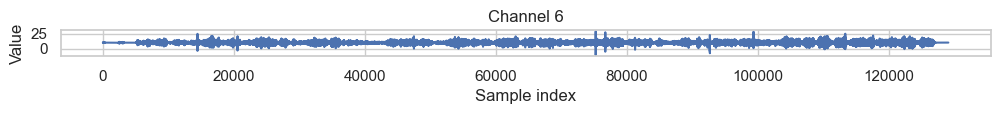

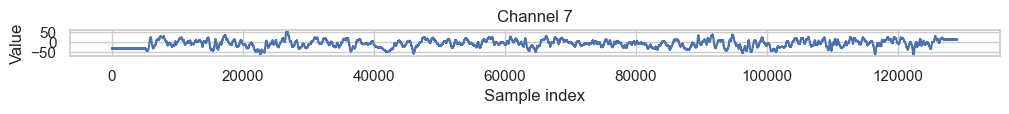

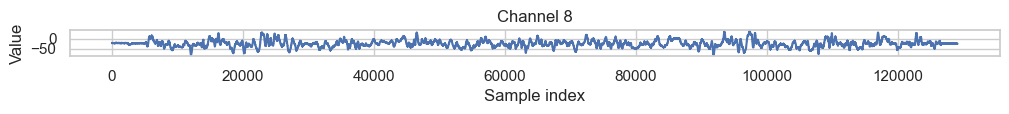

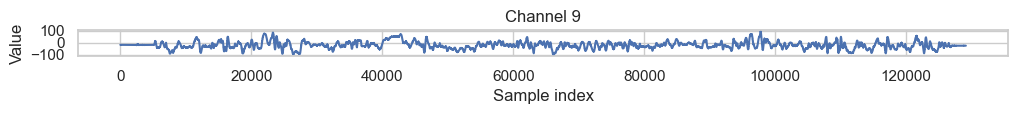

In [16]:
raw, gt, office = load_sample("train_dataset")

num_channels_to_plot =  raw.shape[1]

plt.figure(figsize=(18, 4 * num_channels_to_plot))

for i in range(num_channels_to_plot):
    plt.subplot(num_channels_to_plot, 1, i + 1)
    plt.plot(raw[:, i])
    plt.title(f"Channel {i}")
    plt.xlabel("Sample index")
    plt.ylabel("Value")
    # plt.tight_layout()
    plt.show()

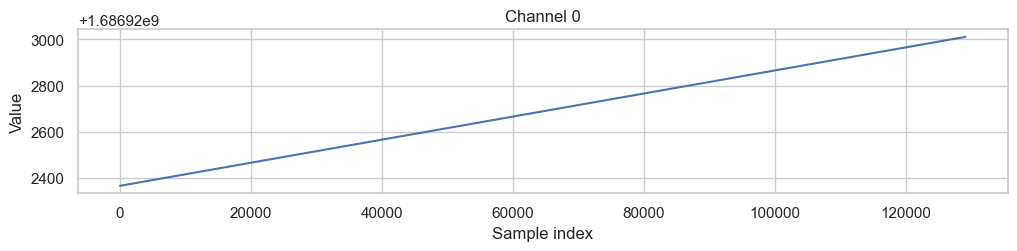

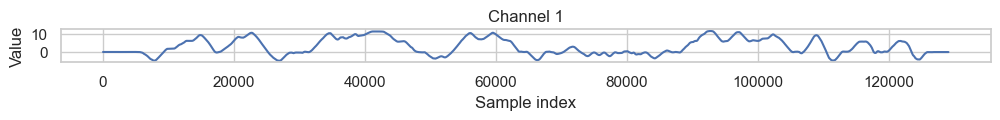

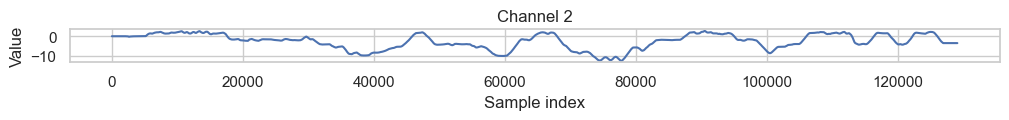

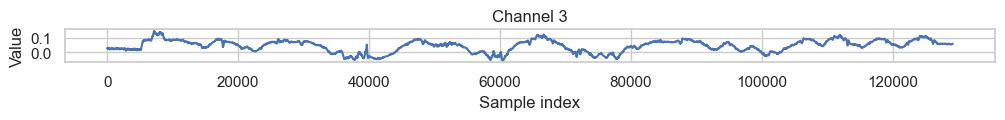

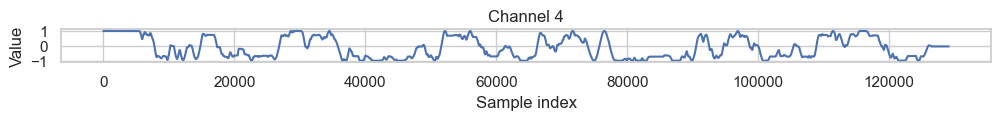

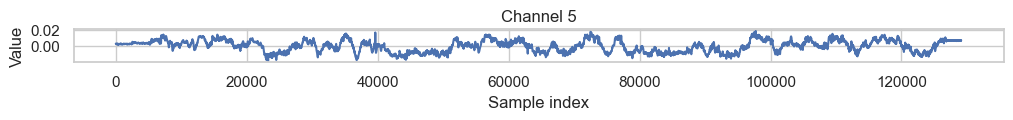

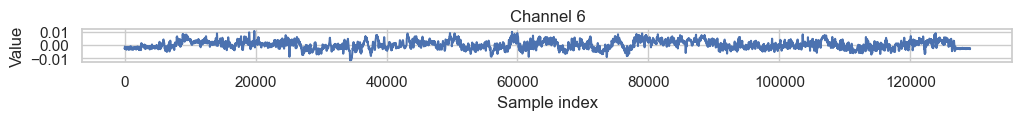

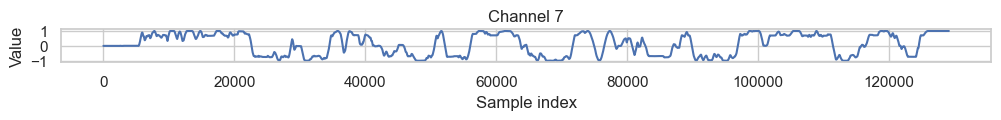

In [7]:
num_channels_to_plot =  gt.shape[1]

plt.figure(figsize=(12, 2.5 * num_channels_to_plot))

for i in range(num_channels_to_plot):
    plt.subplot(num_channels_to_plot, 1, i + 1)
    plt.plot(gt[:, i])
    plt.title(f"Channel {i}")
    plt.xlabel("Sample index")
    plt.ylabel("Value")
    # plt.tight_layout()
    plt.show()

In [8]:
raw, gt, office = load_sample("train_dataset")

timestamp = raw[:, 0]
gyro = raw[:, 1:4]
acce = raw[:, 4:7]
mag  = raw[:, 7:10]

gt_time = gt[:, 0]
pos = gt[:, 1:4]
quat = gt[:, 4:8]


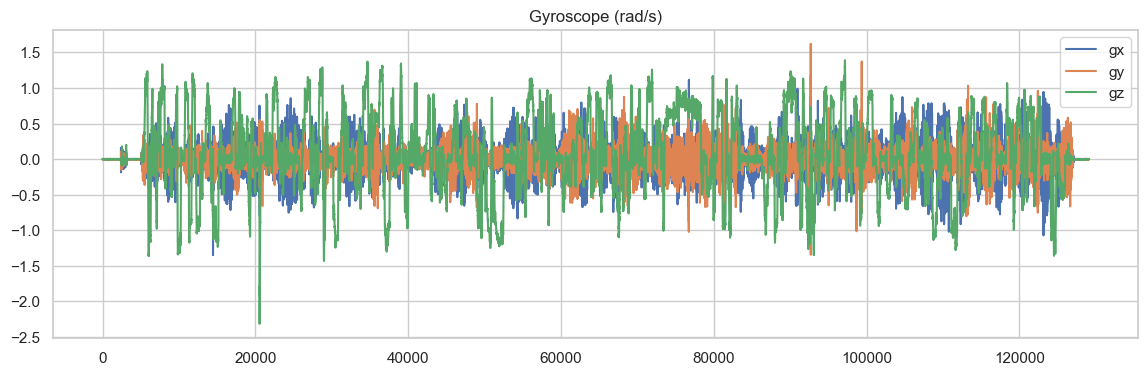

In [9]:
plt.figure(figsize=(14,4))
plt.plot(gyro[:,0], label="gx")
plt.plot(gyro[:,1], label="gy")
plt.plot(gyro[:,2], label="gz")
plt.legend()
plt.title("Gyroscope (rad/s)")
plt.show()

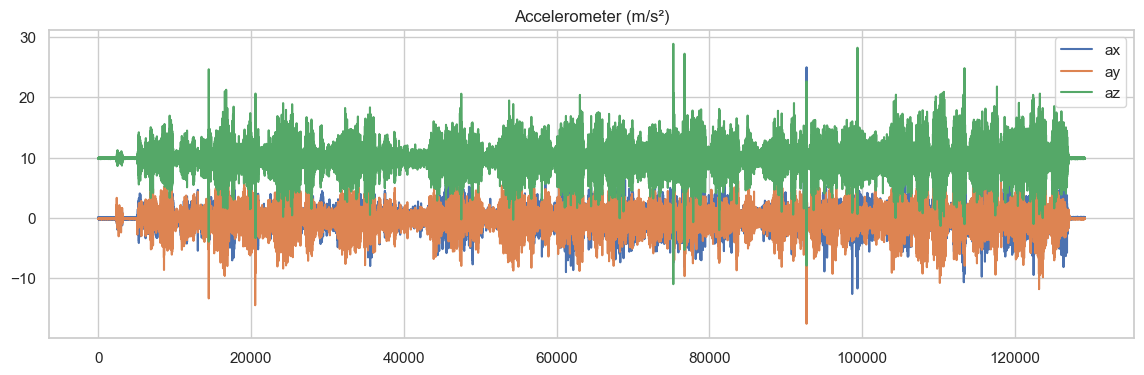

In [10]:
plt.figure(figsize=(14,4))
plt.plot(acce[:,0], label="ax")
plt.plot(acce[:,1], label="ay")
plt.plot(acce[:,2], label="az")
plt.legend()
plt.title("Accelerometer (m/s²)")
plt.show()

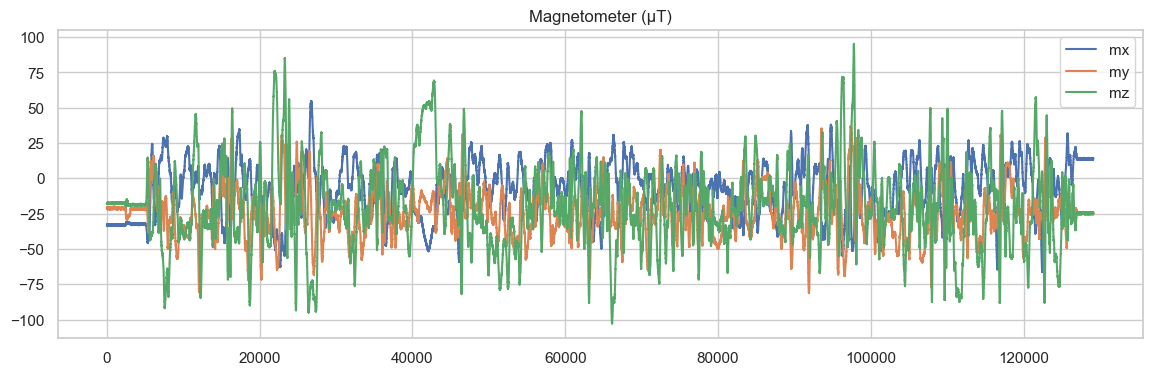

In [11]:
plt.figure(figsize=(14,4))
plt.plot(mag[:,0], label="mx")
plt.plot(mag[:,1], label="my")
plt.plot(mag[:,2], label="mz")
plt.legend()
plt.title("Magnetometer (µT)")
plt.show()

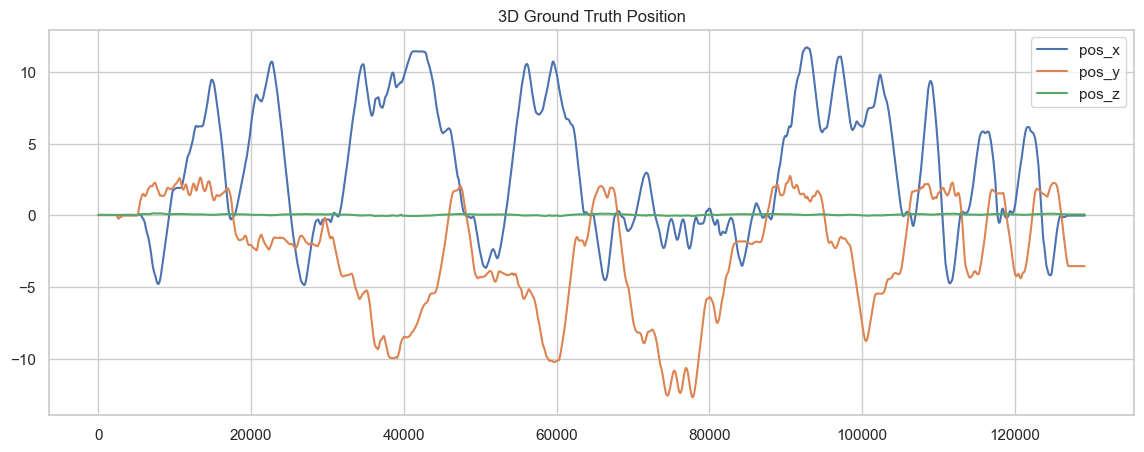

In [12]:
plt.figure(figsize=(14,5))
plt.plot(pos[:,0], label="pos_x")
plt.plot(pos[:,1], label="pos_y")
plt.plot(pos[:,2], label="pos_z")
plt.legend()
plt.title("3D Ground Truth Position")
plt.show()

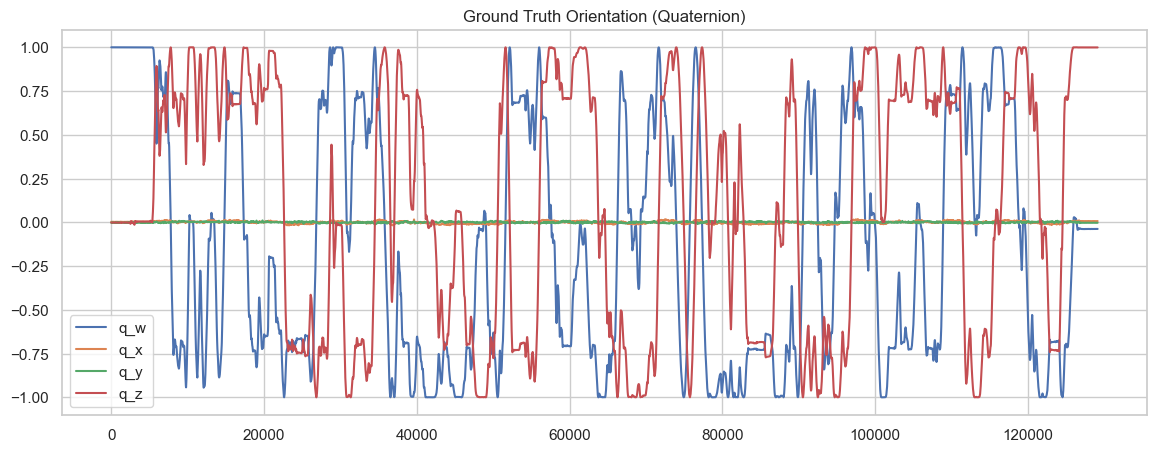

In [13]:
plt.figure(figsize=(14,5))
for i, comp in enumerate(["w", "x", "y", "z"]):
    plt.plot(quat[:, i], label=f"q_{comp}")

plt.legend()
plt.title("Ground Truth Orientation (Quaternion)")
plt.show()

dt mean: 0.005003544735631179 
dt std: 0.001822101398702419
dt percentiles (1,25,50,75,99): [0.00194311 0.00398827 0.00499988 0.00601292 0.0080626 ]


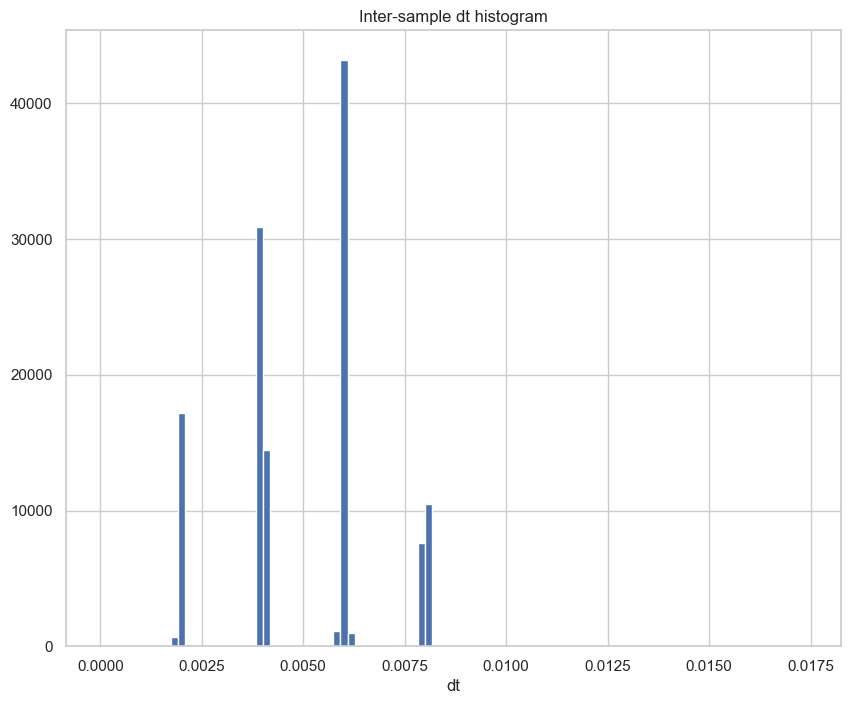

In [20]:
def sampling_stats(timestamp):
    dt = np.diff(timestamp)
    return dt.mean(), dt.std(), np.percentile(dt, [1,25,50,75,99])

dt_mean, dt_std, dt_pct = sampling_stats(timestamp)
print("dt mean:", dt_mean, "\ndt std:", dt_std)
print("dt percentiles (1,25,50,75,99):", dt_pct)

plt.figure(figsize=(10, 8))
plt.hist(np.diff(timestamp), bins=100)
plt.title("Inter-sample dt histogram")
plt.xlabel("dt")
plt.show()

- Mean sampling interval = ~5 ms = ~200Hz
- Sampling Jitter = 0.00182/0.005 = ~36% (high jitter)
    => Sampling intervals are not consistent.

In [14]:
def print_stats(name, data):
    print(f"\n{name} Stats:")
    print(" Mean:", data.mean(axis=0))
    print(" Std :", data.std(axis=0))
    print(" Min :", data.min(axis=0))
    print(" Max :", data.max(axis=0))

print_stats("Gyroscope", gyro)
print_stats("Accelerometer", acce)
print_stats("Magnetometer", mag)

print_stats("Position", pos)
print_stats("Quaternion", quat)


Gyroscope Stats:
 Mean: [-0.00133285 -0.00124645  0.08284336]
 Std : [0.14214519 0.11022212 0.5282569 ]
 Min : [-1.34941562 -1.34459511 -2.31468122]
 Max : [1.16815718 1.62059596 1.38986978]

Accelerometer Stats:
 Mean: [-0.05780699 -0.16072714  9.8711205 ]
 Std : [1.37691867 1.66529037 1.85549337]
 Min : [-15.47294823 -17.5223773  -10.96501891]
 Max : [24.93633503 11.46437845 28.81958058]

Magnetometer Stats:
 Mean: [ -7.77927123 -24.17332605 -20.07991632]
 Std : [18.76355353 16.95290957 29.30667925]
 Min : [ -66.3973337   -81.30426824 -102.97700657]
 Max : [54.74410323 37.20161016 95.3045957 ]

Position Stats:
 Mean: [ 3.02795623 -2.67003468  0.04409117]
 Std : [4.46881222 3.91600496 0.0409378 ]
 Min : [ -4.86686556 -12.70471592  -0.06033377]
 Max : [11.72749544  2.74396632  0.14935269]

Quaternion Stats:
 Mean: [-1.30462139e-01 -1.12920017e-04  2.64406846e-04  1.09334545e-01]
 Std : [0.68869777 0.00707681 0.00303999 0.70459634]
 Min : [-0.99997665 -0.0178766  -0.01191868 -0.9999912

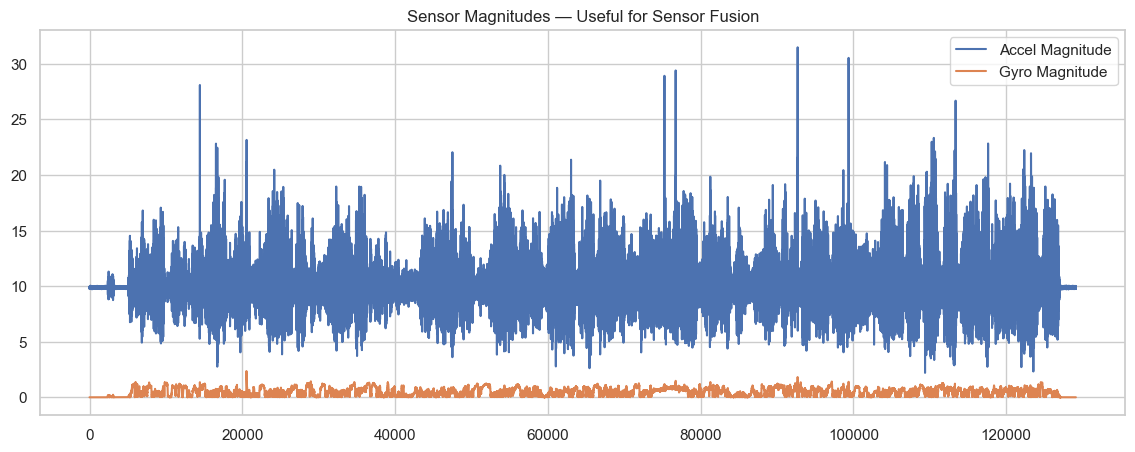

In [15]:
acc_mag = np.linalg.norm(acce, axis=1)
gyro_mag = np.linalg.norm(gyro, axis=1)

plt.figure(figsize=(14,5))
plt.plot(acc_mag, label="Accel Magnitude")
plt.plot(gyro_mag, label="Gyro Magnitude")
plt.legend()
plt.title("Sensor Magnitudes — Useful for Sensor Fusion")
plt.show()

---

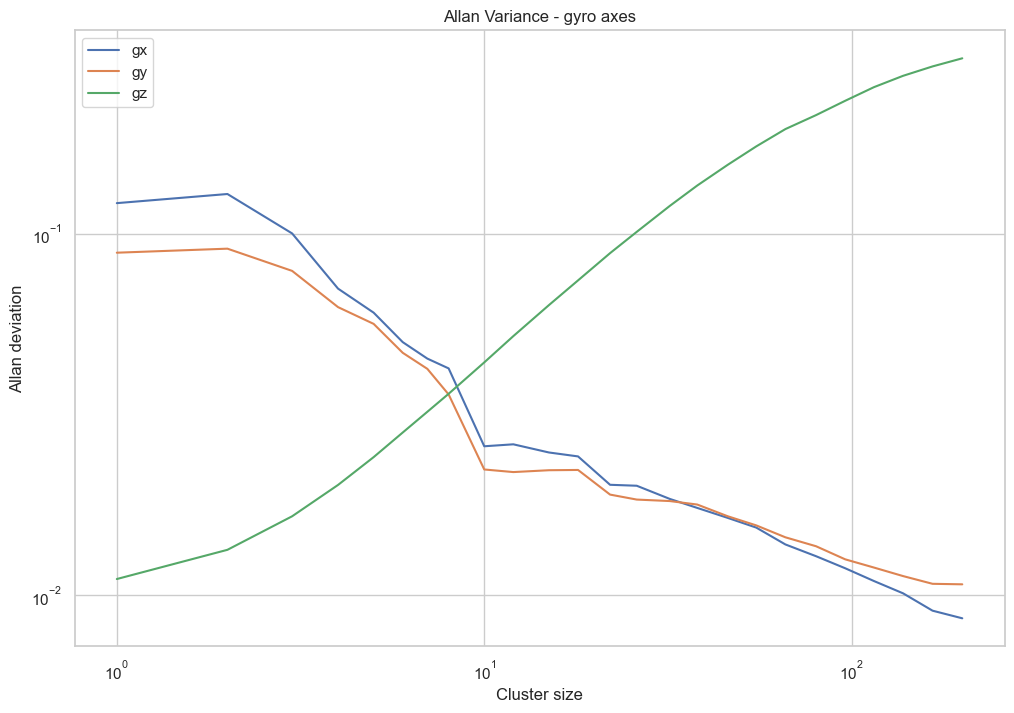

In [ ]:
# Gyro Axes -- log-log plot
def allan_variance(sig, max_m=100): # Analyzes random errors / noise
    N = len(sig)
    av, taus = [], []
    for m in np.unique(np.logspace(0, np.log10(max_m), num=30, dtype=int)):
        if m<1 or m*1.0>=N:
            continue
        trimmed = (N // m) * m
        x = sig[:trimmed].reshape(-1, m).mean(axis=1)
        av.append(0.5 * np.mean(np.diff(x)**2))
        taus.append(m)

    return np.array(taus), np.array(av)

plt.figure(figsize=(12, 8))
for i, ax in enumerate(["gx", "gy", "gz"]):
    taus, av = allan_variance(gyro[:, i], max_m=200)
    plt.loglog(taus, np.sqrt(av), label=ax)
plt.xlabel("Cluster size")
plt.ylabel("Allan deviation")
plt.title("Allan Variance - gyro axes")
plt.legend()
plt.show()

Approx. Sampling Frequency:  200.00495922941204


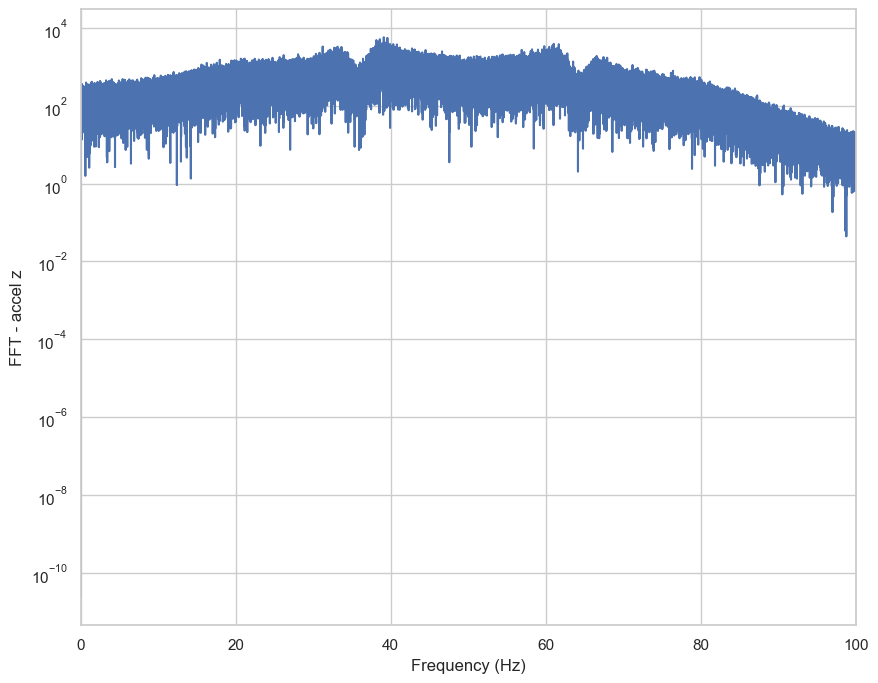

In [ ]:
# FFT of accelerometer 
fs = 1.0/np.median(np.diff(timestamp)) # approx. sampling freq
print("Approx. Sampling Frequency: ", fs)

N = len(acce)
yf = rfft(acce[:,2] - np.mean(acce[:,2]))
xf = rfftfreq(N, 1/fs)

plt.figure(figsize=(10,8))
plt.semilogy(xf, np.abs(yf))
plt.xlim([0, fs/2])     # 0-100 Hz
# y-axis shows FFT magnitude in log scale
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT - accel z")
plt.show()

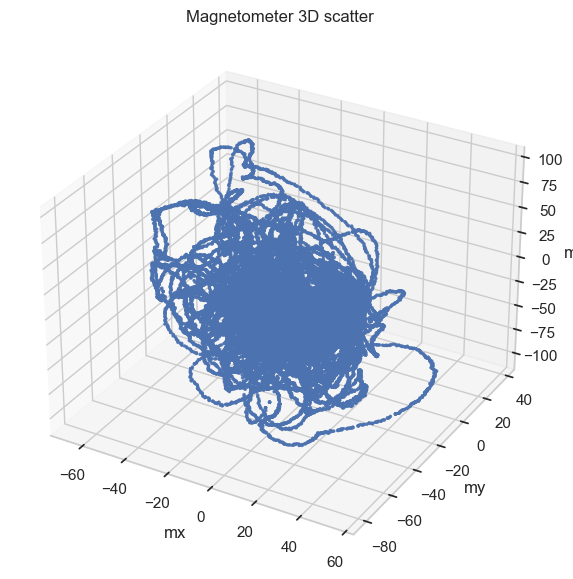

mag center:  [ -7.77927123 -24.17332605 -20.07991632]


In [23]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mag[:, 0], mag[:, 1], mag[:, 2], s=2, alpha=0.6)
ax.set_xlabel("mx")
ax.set_ylabel("my")
ax.set_zlabel("mz")
ax.set_title("Magnetometer 3D scatter")
plt.show()

center = mag.mean(axis=0)
print("mag center: ", center)

| Plot                        | What It Reveals                                                    | What Action to Take                                                     |
| --------------------------- | ----------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| **FFT (accelerometer)**     | Vibration peaks at 30–70 Hz, colored noise, energy < 50 Hz | Low-pass filter at 20–30 Hz, possible downsampling                      |
| **Allan variance (gyro)**   | Good ARW; bias instability (esp. Z-axis); drift exists     | Gyro bias estimation; use complementary/Mahony/Madgwick; EKF bias model |
| **Magnetometer 3D scatter** | Hard-iron bias; soft-iron distortion; ellipsoid shape      | Full magnetometer calibration (bias + scale + rotation)                 |


---

In [34]:
def quaternion_inverse(q):
    """Inverse of a quaternion q = [w, x, y, z]."""
    w, x, y, z = q.T
    norm_sq = w*w + x*x + y*y + z*z
    return np.column_stack((w, -x, -y, -z)) / norm_sq[:, None]

def quaternion_multiply(q1, q2):
    """Quaternion multiplication q1 ⊗ q2."""
    w1, x1, y1, z1 = q1.T
    w2, x2, y2, z2 = q2.T
    
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    
    return np.column_stack((w, x, y, z))

def compute_angular_velocity_from_quat(timestamps, quats):
    """
    Computes angular velocity (rad/s) from quaternion time series.
    timestamps: array (N,)
    quats: array (N,4) in format [w, x, y, z]
    """
    quats = np.asarray(quats)
    timestamps = np.asarray(timestamps)

    # Compute quaternion derivative dq/dt
    dq = np.diff(quats, axis=0)
    dt = np.diff(timestamps)
    dqdt = dq / dt[:, None]

    # Align sizes (dqdt is N-1)
    q_mid = quats[:-1]

    # Compute q_inv ⊗ dq/dt
    q_inv = quaternion_inverse(q_mid)
    omega_quat = quaternion_multiply(q_inv, dqdt)

    # Angular velocity is 2 * vector part (x, y, z)
    omega = 2 * omega_quat[:, 1:]  # drop scalar w
    return omega


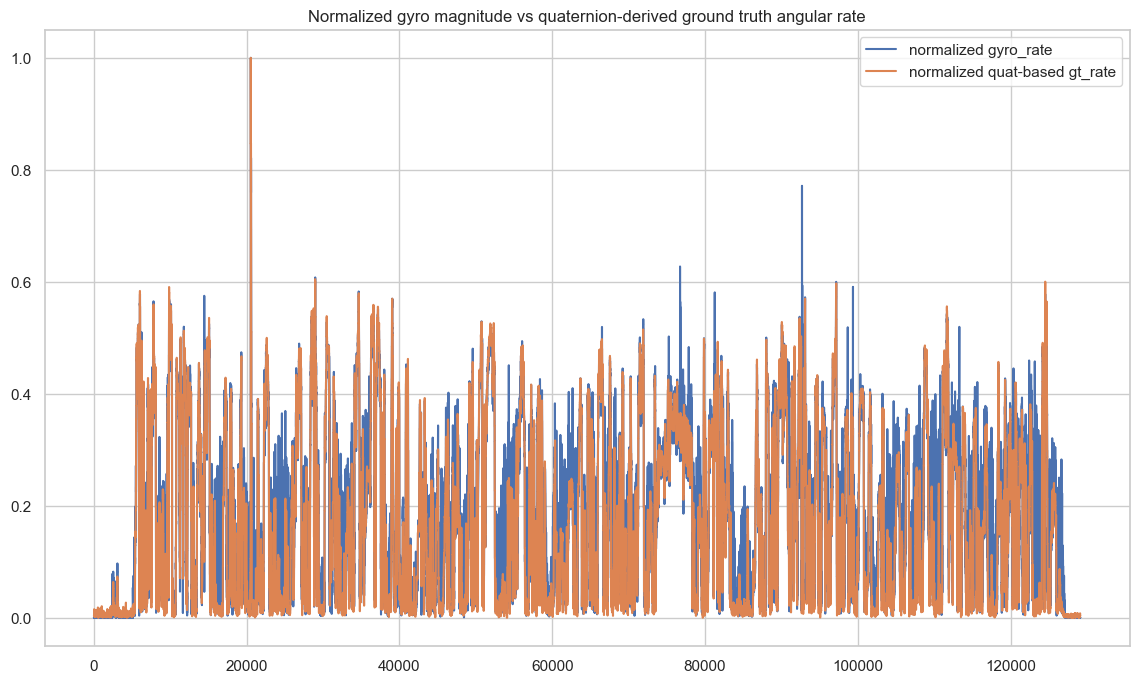

In [36]:
# Compute ground truth angular velocity from quaternions
gt_omega = compute_angular_velocity_from_quat(timestamp, quat)

# normalize for plotting
norm_gyro_mag = (gyro_mag - gyro_mag.min()) / (gyro_mag.max() - gyro_mag.min())
norm_gt_omega_mag = np.linalg.norm(gt_omega, axis=1)
norm_gt_omega_mag = (norm_gt_omega_mag - norm_gt_omega_mag.min()) / (norm_gt_omega_mag.max() - norm_gt_omega_mag.min())

plt.figure(figsize=(14,8))
plt.plot(norm_gyro_mag[:len(norm_gt_omega_mag)], label="normalized gyro_rate")
plt.plot(norm_gt_omega_mag, label="normalized quat-based gt_rate")
plt.title("Normalized gyro magnitude vs quaternion-derived ground truth angular rate")
plt.legend()
plt.show()

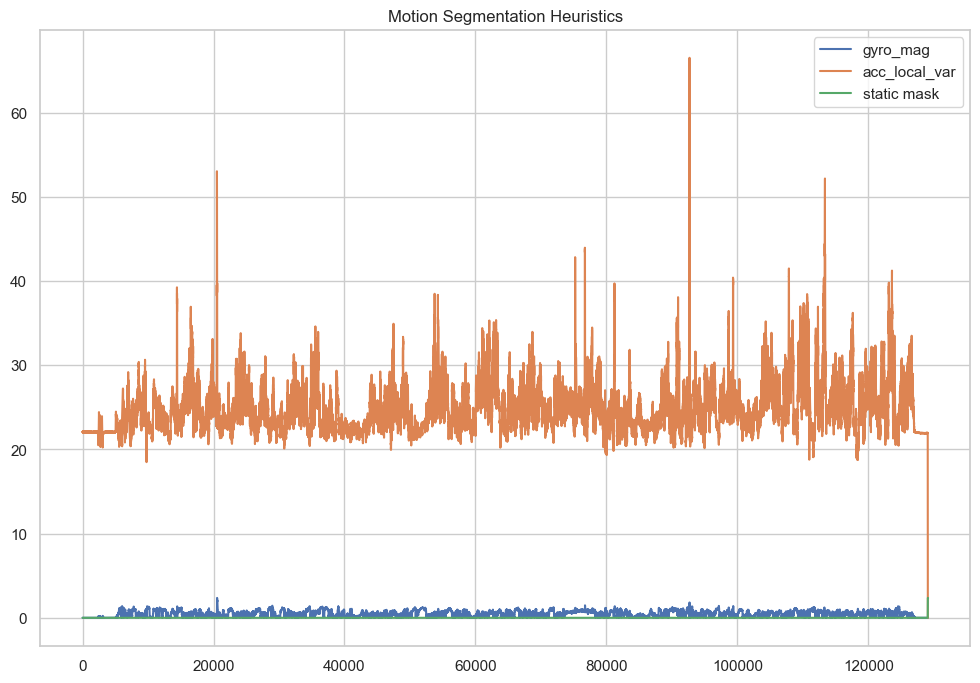

Static fraction: 0.00037947137314426883


In [31]:
# Motion segmentation
gyro_mag = np.linalg.norm(gyro, axis=1)
accel_mag = np.linalg.norm(acce, axis=1)

gyro_thresh = np.percentile(gyro_mag, 50) * 0.5
acc_var_window = 50
acc_var = np.array([acce[i:i+acc_var_window].var() if i+acc_var_window <= len(acce) else 0 for i in range(len(acce))])

static_mask = (gyro_mag < gyro_thresh) & (acc_var < np.percentile(acc_var, 50) * 0.5)

plt.figure(figsize=(12,8))
plt.plot(gyro_mag, label="gyro_mag")
plt.plot(acc_var, label="acc_local_var")
plt.plot(static_mask.astype(int) * np.max(gyro_mag), label="static mask")
plt.legend()
plt.title("Motion Segmentation Heuristics")
plt.show()

print(f"Static fraction: {static_mask.mean()}")